# FOMC Drift : from hypothesis to verdict

The first strategy of the course. One idea, eight trades a year, real bid/ask prices, and a kill criterion written before the result.

**The hypothesis (Pass 1 of the sheet).** Before a scheduled Fed decision, funds cut their dollar exposure. They do it in advance, because positions are large and spreads widen near the announcement. Liquidity providers take the other side and charge a premium. We take the liquidity provider's side: long the other currencies against the dollar over the 24 hours before the announcement, out 5 minutes before it, so we never carry the decision itself.

**What this notebook does**
1. Load minute bid/ask data and the FOMC calendar
2. Look at one trade, then at the average path before announcements
3. Measure every trade, EUR/USD alone, then a 6-leg short-USD basket
4. Equity curve, drawdown, yearly returns at a 10 % vol target
5. Check the pre-registered kill criterion, and record the verdict

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../data_fomc"
BP = 1e4                      # 1 basis point = 0.01 %
EXIT_MIN = 5                  # we exit 5 minutes before the announcement
ENTRY_H = 24                  # we enter 24 hours before

# The short-USD basket: long the pairs quoted XXX/USD, short the pairs quoted USD/XXX
LONG  = ["EURUSD", "GBPUSD", "AUDUSD", "NZDUSD"]
SHORT = ["USDCAD", "USDCHF"]
LEGS = LONG + SHORT

plt.rcParams.update({"figure.figsize": (12, 4.5), "axes.grid": True, "grid.alpha": .3})

## 1. Data

Minute bars with **bid and ask** (not just a mid price) for each pair, on a window around every FOMC since 2012. The calendar holds the scheduled announcement times in UTC.

In [2]:
bars = pd.read_parquet(f"{DATA}/dukascopy_fomc_minute.parquet")
bars["ts_utc"] = pd.to_datetime(bars["ts_utc"], utc=True)

cal = pd.read_csv(f"{DATA}/event_calendar.csv")
cal["announce_utc"] = pd.to_datetime(cal["announce_utc"], utc=True)
fomc = cal[cal.event == "FOMC"].sort_values("announce_utc").reset_index(drop=True)

# one DataFrame per pair, indexed by time, for fast lookups
books = {p: bars[bars.instrument == p].set_index("ts_utc").sort_index() for p in LEGS}

last_bar = min(b.index.max() for b in books.values())
meetings = [a for a in fomc.announce_utc if a <= last_bar]
print(f"{len(meetings)} FOMC meetings with data, {meetings[0].date()} -> {meetings[-1].date()}")
books["EURUSD"].head(3)

117 FOMC meetings with data, 2012-01-25 -> 2026-09-16


,instrument,bid_open,bid_high,bid_low,bid_close,ask_open,ask_high,ask_low,ask_close,n_ticks
ts_utc,,,,,,,,,,
2012-01-24 18:00:00+00:00,EURUSD,1.30215,1.30220,1.30199,1.30201,1.30223,1.30227,1.30204,1.30208,92
2012-01-24 18:01:00+00:00,EURUSD,1.30201,1.30235,1.30201,1.30232,1.30208,1.30242,1.30208,1.30240,93
2012-01-24 18:02:00+00:00,EURUSD,1.30232,1.30239,1.30223,1.30236,1.30241,1.30246,1.30230,1.30246,79


## 2. One trade, then the average path

The function below finds the **last bar at or before** a timestamp. Never a bar after it: that would be looking into the future.

In [3]:
def bar_at(pair, ts, tolerance_min=12):
    """Last minute bar <= ts. Returns None if the closest bar is too old (data gap)."""
    book = books[pair]
    i = book.index.searchsorted(ts, side="right") - 1
    if i < 0 or (ts - book.index[i]) > pd.Timedelta(minutes=tolerance_min):
        return None
    return book.iloc[i]

def trade_return(pair, announce, exit_min=EXIT_MIN, net=True):
    """Return of one short-USD trade on one pair, entry at T-24h, exit at T-exit_min.
    net=True  : buy at the ask, sell at the bid (what you actually pay)
    net=False : mid-to-mid (gross, for comparison)"""
    e = bar_at(pair, announce - pd.Timedelta(hours=ENTRY_H))
    x = bar_at(pair, announce - pd.Timedelta(minutes=exit_min))
    if e is None or x is None:
        return np.nan
    if not net:
        mid_e, mid_x = (e.bid_close + e.ask_close) / 2, (x.bid_close + x.ask_close) / 2
        r = mid_x / mid_e - 1
        return r if pair in LONG else -r
    if pair in LONG:                      # long XXX/USD: buy ask, sell bid
        return x.bid_close / e.ask_close - 1
    return (e.bid_close - x.ask_close) / e.bid_close   # short USD/XXX: sell bid, buy back ask

a = meetings[40]
print(f"Meeting {a.date()} : EUR/USD trade = {trade_return('EURUSD', a) * BP:+.1f} bp net")

Meeting 2017-02-01 : EUR/USD trade = -48.2 bp net


**The average path.** Take every meeting, align the 24 hours before it, average the basket's cumulative return hour by hour. This is the picture that turned an idea into a hypothesis: a slow drift, then the announcement.

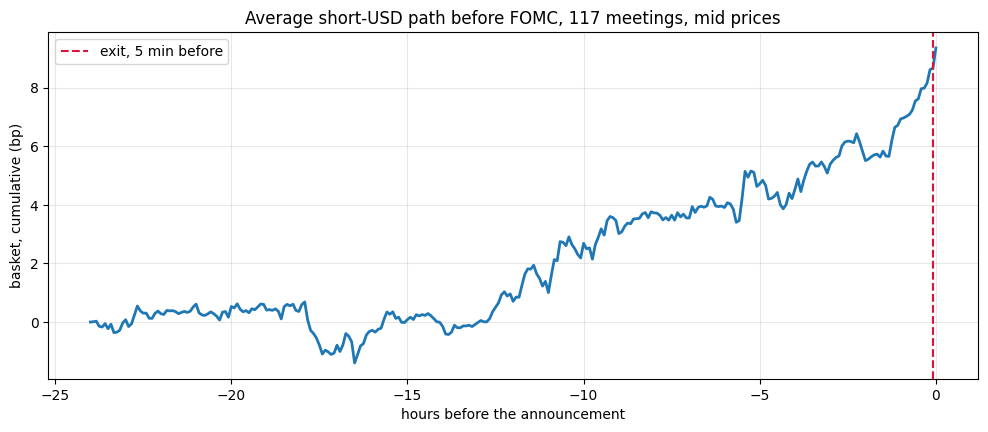

In [4]:
def path_before(announce, pair, hours=ENTRY_H):
    """Cumulative mid return of a short-USD position, minute by minute, over the 24h before."""
    book = books[pair]
    w = book.loc[announce - pd.Timedelta(hours=hours): announce]
    if len(w) < 60:
        return None
    mid = (w.bid_close + w.ask_close) / 2
    r = mid / mid.iloc[0] - 1
    r = r if pair in LONG else -r
    r.index = (r.index - announce).total_seconds() / 3600     # hours to announcement (negative)
    return r

paths = []
for a in meetings:
    legs = [path_before(a, p) for p in LEGS]
    legs = [l for l in legs if l is not None]
    if len(legs) >= 5:
        # resample each leg to a common 5-minute grid, then average the legs
        grid = np.arange(-ENTRY_H, 0.001, 5 / 60)
        legs = [np.interp(grid, l.index.values, l.values) for l in legs]
        paths.append(np.mean(legs, axis=0))
avg_path = pd.Series(np.mean(paths, axis=0) * BP, index=grid)

ax = avg_path.plot(lw=2)
ax.axvline(-EXIT_MIN / 60, color="crimson", ls="--", label="exit, 5 min before")
ax.set_xlabel("hours before the announcement"); ax.set_ylabel("basket, cumulative (bp)")
ax.set_title(f"Average short-USD path before FOMC, {len(paths)} meetings, mid prices")
ax.legend(); plt.show()

## 3. Every trade

First EUR/USD alone (the v1 of the strategy), then the 6-leg basket (v2). We split the sample **before looking**: in-sample before 2019, out-of-sample 2019-2024, and "fresh" data from 2025 that arrived after the strategy went live.

In [5]:
def stats(x):
    """Mean per trade in bp, t-stat, hit rate, number of trades."""
    x = pd.Series(x).dropna()
    n = len(x)
    t = x.mean() / (x.std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan
    return pd.Series({"mean (bp)": x.mean() * BP, "t-stat": t, "hit %": (x > 0).mean() * 100, "trades": n})

def by_split(s):
    return pd.DataFrame({
        "IS  2012-2018": stats(s[:"2018"]),
        "OOS 2019-2024": stats(s["2019":"2024"]),
        "Fresh 2025-26": stats(s["2025":]),
        "Full":          stats(s),
    }).T.round(2)

eur = pd.Series({a: trade_return("EURUSD", a) for a in meetings})
eur.index = eur.index.tz_convert(None)
print("EUR/USD alone, net bid/ask")
by_split(eur)

EUR/USD alone, net bid/ask


,mean (bp),t-stat,hit %,trades
IS 2012-2018,13.62,2.78,66.07,56.0
OOS 2019-2024,9.77,2.12,59.57,47.0
Fresh 2025-26,-17.83,-2.50,21.43,14.0
Full,8.31,2.58,58.12,117.0


In [6]:
basket, legs_detail = {}, {}
for a in meetings:
    legs = {p: trade_return(p, a) for p in LEGS}
    ok = [p for p in LEGS if not np.isnan(legs[p])]
    if len(ok) >= 5:                                   # at least 5 of 6 legs must have data
        basket[a] = np.mean([legs[p] for p in ok])
        legs_detail[a] = legs
r = pd.Series(basket).sort_index(); r.index = r.index.tz_convert(None)
legs_detail = pd.DataFrame(legs_detail).T.sort_index(); legs_detail.index = legs_detail.index.tz_convert(None)

print("6-leg short-USD basket, net bid/ask")
by_split(r)

6-leg short-USD basket, net bid/ask


,mean (bp),t-stat,hit %,trades
IS 2012-2018,10.86,2.85,64.29,56.0
OOS 2019-2024,11.62,2.75,61.70,47.0
Fresh 2025-26,-18.54,-3.37,14.29,14.0
Full,7.65,2.82,57.26,117.0


**When does an out-of-sample result say "dead" rather than "a bad patch"?** The rule was written before looking, in Pass 1: compare the OOS mean to the IS mean, three zones. Above half the IS mean: confirms. Between −½ and +½: ambiguous, wait. Below −½ *and* OOS t-stat under −1.5: contradicts, kill. Losing half of an edge out of sample is normal; a reversed sign with a significant t is not.

In [7]:
is_mean = basket_is = r[:"2018"].mean() * BP
def zone(sub):
    m, t = sub.mean() * BP, stats(sub)["t-stat"]
    if m > is_mean / 2:                       return "confirms"
    if m < -is_mean / 2 and t < -1.5:         return "contradicts -> kill"
    return "ambiguous -> wait"
print(f"IS mean {is_mean:+.1f} bp ; thresholds at {is_mean/2:+.1f} / {-is_mean/2:+.1f} bp")
for name, sub in [("OOS 2019-2024", r["2019":"2024"]), ("Fresh 2025-2026", r["2025":])]:
    print(f"  {name:16s} mean {sub.mean()*BP:+6.1f} bp, t {stats(sub)['t-stat']:+.2f}  ->  {zone(sub)}")

IS mean +10.9 bp ; thresholds at +5.4 / -5.4 bp
  OOS 2019-2024    mean  +11.6 bp, t +2.75  ->  confirms
  Fresh 2025-2026  mean  -18.5 bp, t -3.37  ->  contradicts -> kill


Read the table top-down. In-sample and out-of-sample agree: about +11 bp per trade, t-stat close to 3, six trades out of ten positive. That is a strategy that passed. Then the fresh data: **−18 bp, t = −3.4, two winners in fourteen**. Same code, same rules. The market changed.

The last meetings, leg by leg, to check it is not one pair misbehaving:

In [8]:
recent = (legs_detail["2025":] * BP).round(1)
recent["BASKET"] = (r["2025":] * BP).round(1)
recent

,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDCAD,USDCHF,BASKET
2025-01-29 19:00:00,-9.3,10.4,-29.1,-23.5,-18.5,-27.1,-16.2
2025-03-19 18:00:00,-75.2,-35.1,-63.8,-72.3,-26.7,-50.0,-53.9
2025-05-07 18:00:00,-18.7,-22.7,-61.8,-56.5,-21.3,12.5,-28.1
2025-06-18 18:00:00,11.7,NaN,56.8,24.8,-37.8,-24.0,6.3
2025-07-30 18:00:00,-54.3,-38.5,-75.4,-53.7,-25.1,-53.1,-50.0
2025-09-17 18:00:00,-13.4,4.2,-26.5,-28.2,-14.1,-10.4,-14.7
2025-10-29 18:00:00,-12.5,-35.9,37.2,9.9,33.1,-47.4,-2.6
2025-12-10 19:00:00,28.1,26.5,2.0,6.4,12.2,46.5,20.3
2026-01-28 19:00:00,-45.2,-2.9,12.5,13.3,10.4,-60.5,-12.1
2026-03-18 18:00:00,-21.7,-16.2,-42.6,-44.3,-7.1,-65.2,-32.9


## 4. Equity, drawdown, yearly returns

Constant leverage so that the whole history runs at 10 % annualised vol. This is a display convention (the leverage is calibrated on the full sample), not a point-in-time sizing.

Range of outcomes if the 117 trades had come in a different order or mix (bootstrap, 5-95 %):
                  5 %  median  95 %
Sharpe           0.34    0.75  1.16
Max drawdown % -27.67  -16.01 -9.79

117 trades, 8.0 per year | Sharpe 0.74 | CAGR +7.1 % | max drawdown -29.5 % | positive years 11/15


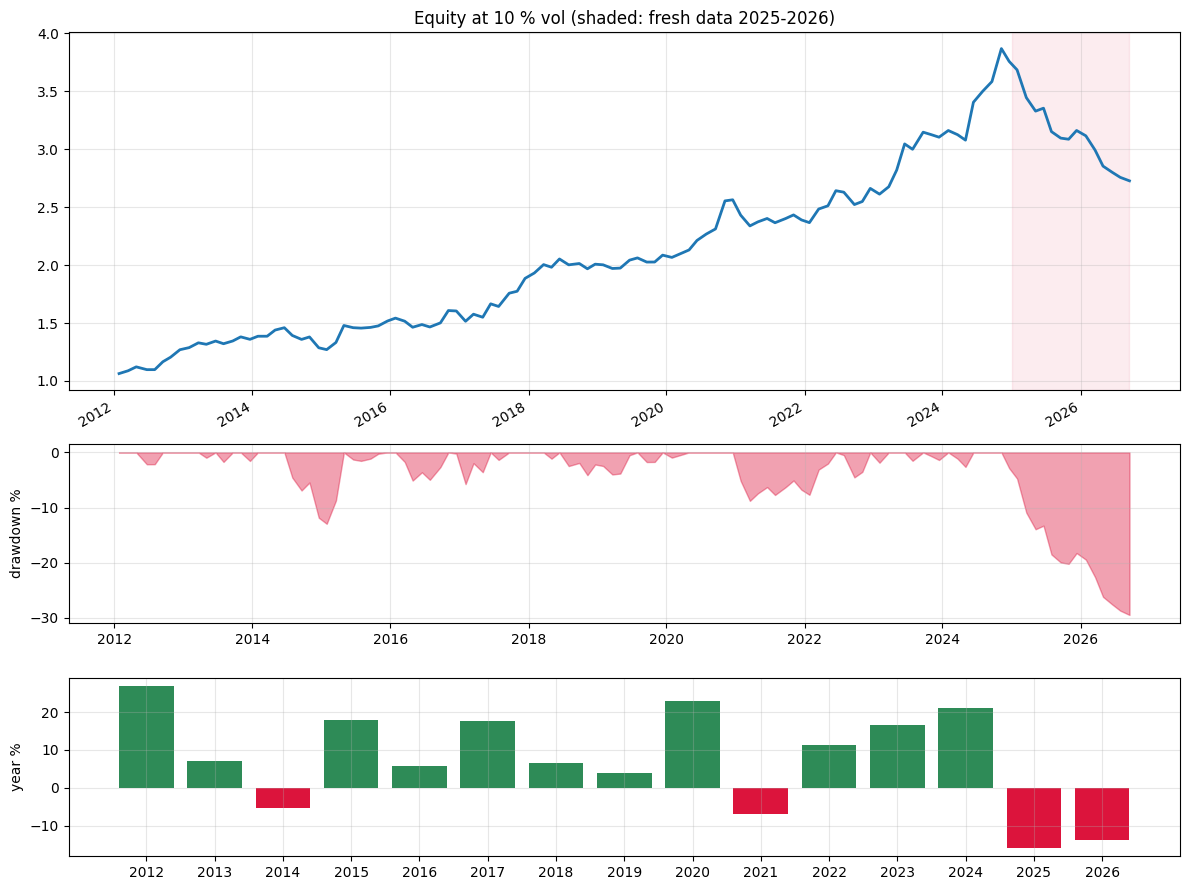

In [9]:
years = (r.index.max() - r.index.min()).days / 365.25
trades_per_year = len(r) / years
lev = 0.10 / (r.std(ddof=1) * np.sqrt(trades_per_year))      # leverage for 10 % vol
rv = r * lev
equity = (1 + rv).cumprod()
drawdown = equity / equity.cummax() - 1
sharpe = r.mean() / r.std(ddof=1) * np.sqrt(trades_per_year)
yearly = rv.groupby(rv.index.year).apply(lambda s: (1 + s).prod() - 1)

def bootstrap_ranges(x, n=5000, seed=0):
    # resample the trades with replacement: what else could 117 trades have looked like?
    a, rng, out = x.values, np.random.default_rng(seed), []
    for _ in range(n):
        s = a[rng.integers(0, len(a), len(a))]
        eq = np.cumprod(1 + s * lev)
        out.append((s.mean() / s.std() * np.sqrt(trades_per_year), (eq / np.maximum.accumulate(eq) - 1).min() * 100))
    out = pd.DataFrame(out, columns=["Sharpe", "Max drawdown %"])
    return out.quantile([0.05, 0.5, 0.95]).T.rename(columns={0.05: "5 %", 0.5: "median", 0.95: "95 %"})

print("Range of outcomes if the 117 trades had come in a different order or mix (bootstrap, 5-95 %):")
print(bootstrap_ranges(r).round(2).to_string())
print()
print(f"{len(r)} trades, {trades_per_year:.1f} per year | Sharpe {sharpe:.2f} | "
      f"CAGR {(equity.iloc[-1] ** (1 / years) - 1) * 100:+.1f} % | max drawdown {drawdown.min() * 100:.1f} % | "
      f"positive years {(yearly > 0).sum()}/{len(yearly)}")

fig, ax = plt.subplots(3, 1, figsize=(12, 9), height_ratios=[2, 1, 1], sharex=False)
equity.plot(ax=ax[0], lw=2); ax[0].axvspan(pd.Timestamp("2025-01-01"), equity.index.max(), color="crimson", alpha=.08)
ax[0].set_title("Equity at 10 % vol (shaded: fresh data 2025-2026)")
ax[1].fill_between(drawdown.index, drawdown * 100, 0, color="crimson", alpha=.4); ax[1].set_ylabel("drawdown %")
ax[2].bar(yearly.index.astype(str), yearly * 100, color=["seagreen" if v > 0 else "crimson" for v in yearly]); ax[2].set_ylabel("year %")
plt.tight_layout(); plt.show()

## 5. The exit criterion (live)

Written in Pass 1 (box 1.8), before going live: **drawdown of the 10 %-vol equity below −20 %**, evaluated as it would have been seen at the time. One rule, one question: did it fire, and when?

(Comparing rules of different speeds, and how to monitor a live strategy, is lesson 3.5.)

Drawdown stop fired on 2025-10-29. Trades after the cut: 7, average -14.3 bp.


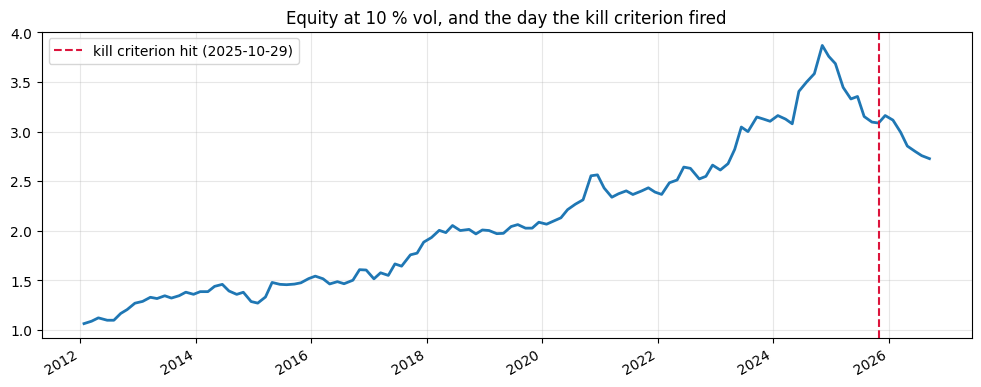

In [10]:
stop_date = drawdown[drawdown < -0.20].index.min()
after = r[r.index > stop_date]
print(f"Drawdown stop fired on {stop_date.date()}. Trades after the cut: {len(after)}, average {after.mean() * BP:+.1f} bp.")

ax = equity.plot(lw=2)
ax.axvline(stop_date, color="crimson", ls="--", lw=1.5, label=f"kill criterion hit ({stop_date.date()})")
ax.set_title("Equity at 10 % vol, and the day the kill criterion fired"); ax.legend(); plt.show()

## Verdict

- **2012-2024: the edge held.** +11 bp per trade, in-sample and out-of-sample, t ≈ 2.8 both times.
- **2025-2026: it reversed.** −18 bp per trade, 2 winners out of 14. Not one pair: almost every leg on the same meetings. The dollar is now bid into the announcement.
- **The kill criterion fired on 2025-10-29.** The seven trades after it averaged −14 bp: cutting was right.
- **Why it stopped is not understood.** Rates, positioning and volatility were checked: no reliable relation. An edge can die without an explanation. That is exactly why the stop had to be mechanical, written before the result.

**Status: killed.** The strategy sheet moves to `2 Strategies/Killed/`, the reason goes in the Research Log, and the strategy stays in the vault as evidence.